#### ============================================================
## 🛒 FreshGuard — Retail Food Waste & Spoilage Prediction
#### ============================================================
#### Author    : Selma Alpkaya
#### Goal      : Predict food waste and spoilage in retail stores
####             using Machine Learning & Time Series Analysis
####  Dataset   :Open Food Facts
#### Tools     : Python, Pandas, XGBoost, Prophet, Streamlit
#### *============================================================*

## 1. Exploratory Data Analysis (EDA)

We are working with 500,000 food products from Open Food Facts.
Before building any model, we need to understand the data.

**Key questions we answer here:**
- Which food categories are most common?
- How is the Nutriscore distributed across products?
- Are there data quality issues we need to fix?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("done")

done


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget -q -O '/content/drive/MyDrive/openfoodfacts.csv.gz' https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz
print("Download complete!")

İndirme tamamlandı!


In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/openfoodfacts.csv.gz',
                 compression='gzip',
                 sep='\t',
                 on_bad_lines='skip',
                 low_memory=False,
                 nrows=500000)

print(df.shape)
print(df.head())

(500000, 211)
   code                                                url  creator  \
0    54  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
1    63  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
2   114  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
3   431  http://world-en.openfoodfacts.org/product/0000...  kiliweb   
4   105  http://world-en.openfoodfacts.org/product/0000...  kiliweb   

    created_t      created_datetime  last_modified_t last_modified_datetime  \
0  1582569031  2020-02-24T18:30:31Z       1733085204   2024-12-01T20:33:24Z   
1  1673620307  2023-01-13T14:31:47Z       1750061386   2025-06-16T08:09:46Z   
2  1580066482  2020-01-26T19:21:22Z       1751035658   2025-06-27T14:47:38Z   
3  1714301712  2024-04-28T10:55:12Z       1714301721   2024-04-28T10:55:21Z   
4  1572117743  2019-10-26T19:22:23Z       1738073570   2025-01-28T14:12:50Z   

  last_modified_by  last_updated_t last_updated_datetime  ... choline_100g  \
0     

In [6]:
print(df.isnull().mean().sort_values().head(30))

code                         0.000000
url                          0.000000
creator                      0.000000
created_t                    0.000000
created_datetime             0.000000
last_modified_t              0.000000
last_modified_datetime       0.000000
states                       0.000000
completeness                 0.000000
states_en                    0.000000
states_tags                  0.000000
last_updated_t               0.000008
last_updated_datetime        0.000008
pnns_groups_2                0.003276
pnns_groups_1                0.003276
nutriscore_grade             0.003292
countries                    0.003436
countries_en                 0.003438
countries_tags               0.003438
product_name                 0.031434
last_modified_by             0.074758
brands_tags                  0.359190
brands_en                    0.359478
brands                       0.359632
serving_size                 0.372634
serving_quantity             0.378910
last_image_d

## 2. Data Cleaning
Removing unknown categories, impossible values, and filling missing data with median.
After cleaning: 153,187 products remain.

In [7]:
cols = ['product_name', 'pnns_groups_1', 'nutriscore_grade',
        'energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']

df = df[cols]
df = df[df['pnns_groups_1'] != 'unknown']
df = df.dropna(subset=['nutriscore_grade'])

num_cols = ['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print(df.shape)

(174180, 8)


In [8]:
print(df['pnns_groups_1'].value_counts())
print(df['nutriscore_grade'].value_counts())

pnns_groups_1
Sugary snacks              37347
Cereals and potatoes       25459
Fat and sauces             21172
Beverages                  21169
Milk and dairy products    18695
Fish Meat Eggs             15939
Fruits and vegetables      13685
Composite foods            12659
Salty snacks                6920
Alcoholic beverages         1051
Baby foods                    84
Name: count, dtype: int64
nutriscore_grade
e                 48484
d                 35796
c                 29211
a                 23065
unknown           18641
b                 16859
not-applicable     2124
Name: count, dtype: int64


In [9]:
df = df[~df['nutriscore_grade'].isin(['unknown', 'not-applicable'])]
print(df.shape)
print(df['nutriscore_grade'].value_counts())

(153415, 8)
nutriscore_grade
e    48484
d    35796
c    29211
a    23065
b    16859
Name: count, dtype: int64


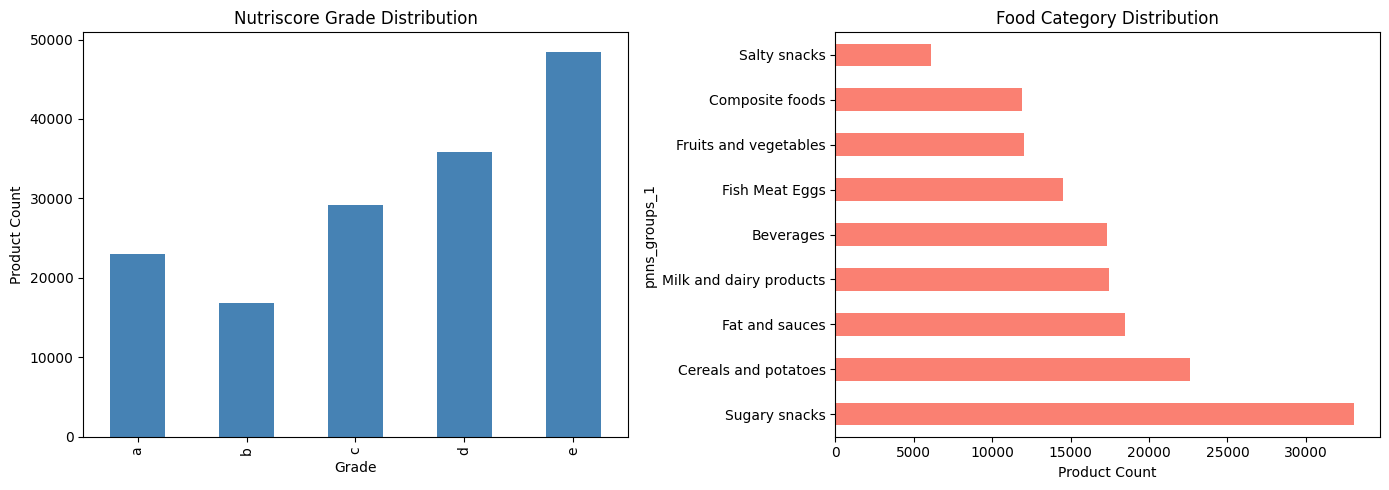

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['nutriscore_grade'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Nutriscore Grade Distribution')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Product Count')

df['pnns_groups_1'].value_counts().plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('Food Category Distribution')
axes[1].set_xlabel('Product Count')

plt.tight_layout()
plt.show()

In [11]:
df = df[df['energy_100g'] < 4000]
df = df[df['fat_100g'] < 100]
df = df[df['sugars_100g'] < 100]
df = df[df['proteins_100g'] < 100]
df = df[df['salt_100g'] < 100]

print(df.shape)

(153141, 8)


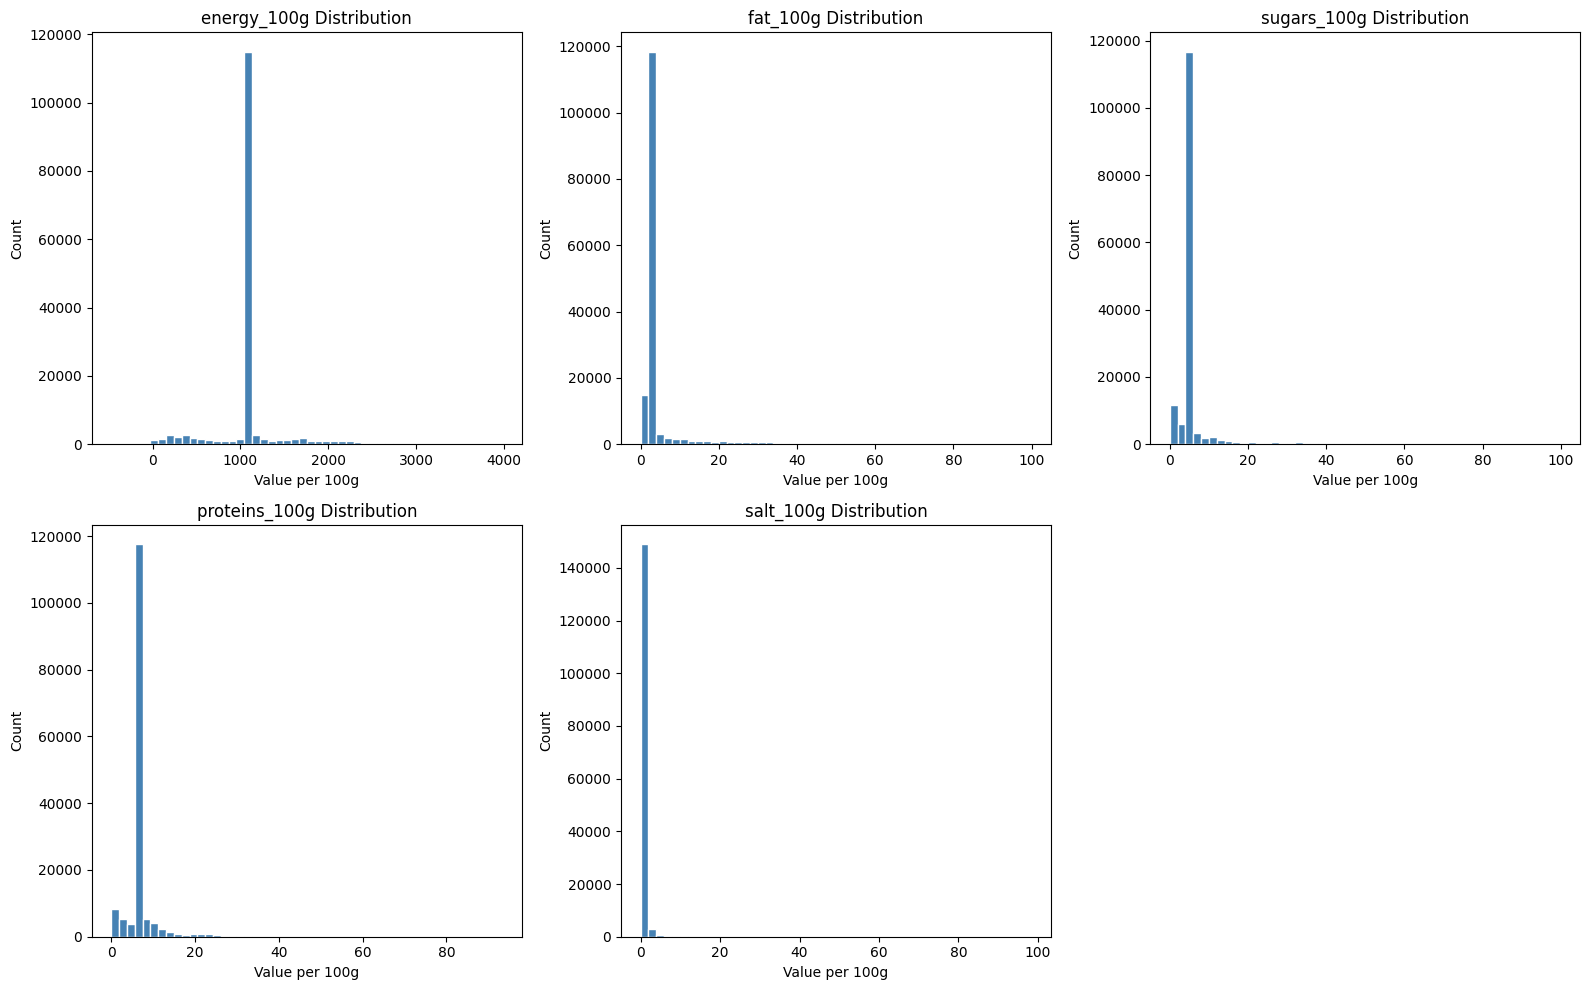

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

num_cols = ['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel('Value per 100g')
    axes[i].set_ylabel('Count')

axes[5].axis('off')
plt.tight_layout()
plt.show()

## 3. Feature Engineering & Modeling
We create new features based on food science knowledge, then train and compare multiple ML models.

In [13]:
from sklearn.model_selection import train_test_split

X = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']]
y = df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}')
print(f'Test: {X_test.shape}')

Train: (122512, 5)
Test: (30629, 5)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.37
              precision    recall  f1-score   support

           a       0.62      0.18      0.28      4631
           b       0.21      0.00      0.01      3406
           c       0.34      0.09      0.15      5810
           d       0.45      0.05      0.10      7113
           e       0.35      0.97      0.52      9669

    accuracy                           0.37     30629
   macro avg       0.40      0.26      0.21     30629
weighted avg       0.40      0.37      0.26     30629



In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print(classification_report(y_test, y_pred))

Accuracy: 0.38
              precision    recall  f1-score   support

           a       0.59      0.20      0.30      4631
           b       0.34      0.06      0.10      3406
           c       0.50      0.13      0.20      5810
           d       0.43      0.04      0.07      7113
           e       0.35      0.97      0.52      9669

    accuracy                           0.38     30629
   macro avg       0.44      0.28      0.24     30629
weighted avg       0.43      0.38      0.28     30629



In [16]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train_scaled, y_train_enc)

y_pred_xgb = xgb.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred_xgb):.2f}')
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

Accuracy: 0.47
              precision    recall  f1-score   support

           a       0.80      0.22      0.35      4631
           b       0.72      0.19      0.30      3406
           c       0.76      0.31      0.44      5810
           d       0.78      0.20      0.32      7113
           e       0.39      0.97      0.56      9669

    accuracy                           0.47     30629
   macro avg       0.69      0.38      0.40     30629
weighted avg       0.65      0.47      0.42     30629



In [17]:
xgb = XGBClassifier(n_estimators=200,
                    random_state=42,
                    eval_metric='mlogloss',
                    scale_pos_weight=1)

from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb.fit(X_train_scaled, y_train_enc, sample_weight=sample_weights)

y_pred_xgb = xgb.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred_xgb):.2f}')
print(classification_report(y_test_enc, y_pred_xgb, target_names=le.classes_))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:06:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.47
              precision    recall  f1-score   support

           a       0.80      0.22      0.35      4631
           b       0.66      0.21      0.32      3406
           c       0.78      0.30      0.44      5810
           d       0.79      0.20      0.32      7113
           e       0.39      0.97      0.56      9669

    accuracy                           0.47     30629
   macro avg       0.68      0.38      0.40     30629
weighted avg       0.65      0.47      0.42     30629



In [18]:
df['fat_sugar_ratio'] = df['fat_100g'] / (df['sugars_100g'] + 1)
df['energy_per_protein'] = df['energy_100g'] / (df['proteins_100g'] + 1)
df['unhealthy_score'] = df['fat_100g'] + df['sugars_100g'] + df['salt_100g']

X = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
        'fat_sugar_ratio', 'energy_per_protein', 'unhealthy_score']]
y = df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb2 = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss')
xgb2.fit(X_train_scaled, y_train_enc, sample_weight=sample_weights)

y_pred = xgb2.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred):.2f}')
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.47
              precision    recall  f1-score   support

           a       0.81      0.22      0.35      4631
           b       0.66      0.21      0.32      3406
           c       0.79      0.30      0.44      5810
           d       0.80      0.21      0.33      7113
           e       0.39      0.98      0.56      9669

    accuracy                           0.47     30629
   macro avg       0.69      0.38      0.40     30629
weighted avg       0.65      0.47      0.42     30629



In [19]:
df['category_enc'] = df['pnns_groups_1'].astype('category').cat.codes

X = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
        'fat_sugar_ratio', 'energy_per_protein', 'unhealthy_score', 'category_enc']]
y = df['nutriscore_grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb3 = XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss')
xgb3.fit(X_train_scaled, y_train_enc, sample_weight=sample_weights)

y_pred = xgb3.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test_enc, y_pred):.2f}')
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.55
              precision    recall  f1-score   support

           a       0.50      0.83      0.63      4631
           b       0.34      0.39      0.36      3406
           c       0.46      0.56      0.50      5810
           d       0.61      0.41      0.49      7113
           e       0.76      0.56      0.65      9669

    accuracy                           0.55     30629
   macro avg       0.53      0.55      0.53     30629
weighted avg       0.58      0.55      0.55     30629



## 4. Model Explainability (SHAP)
We explain WHY the model makes each prediction using SHAP values.

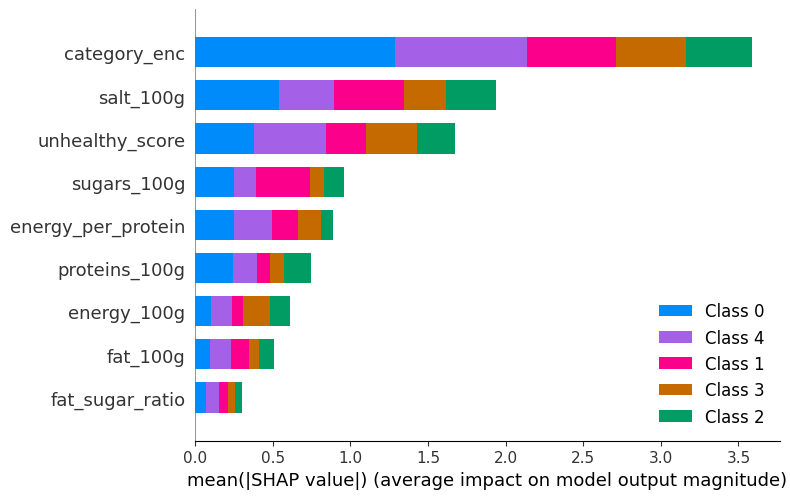

In [20]:
import shap

explainer = shap.TreeExplainer(xgb3)
shap_values = explainer.shap_values(X_test_scaled[:1000])

shap.summary_plot(shap_values, X_test_scaled[:1000],
                  feature_names=X.columns.tolist(),
                  plot_type="bar")

## 5. Clustering
We group products into risk clusters using KMeans to identify high-risk product groups.

In [21]:
from sklearn.cluster import KMeans

X_cluster = df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'unhealthy_score']]
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(df['cluster'].value_counts())

cluster
0    139803
1      6687
2      6651
Name: count, dtype: int64


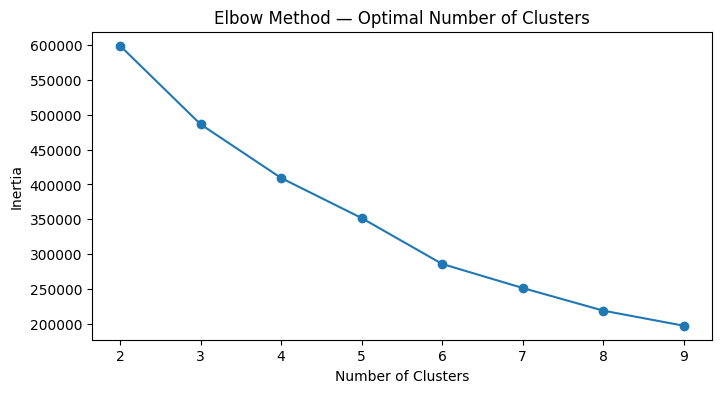

In [22]:
inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_cluster_scaled)

print(df.groupby('cluster')[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']].mean().round(2))

         energy_100g  fat_100g  sugars_100g  proteins_100g  salt_100g
cluster                                                              
0            1033.08      3.71         5.18           6.52       0.68
1            1724.65     12.97        44.01           4.66       0.62
2            2402.56     45.11         6.72           9.49       1.09
3            1239.59     16.08         2.69          21.37       1.79
4             683.97      4.63         8.77           7.67      18.00


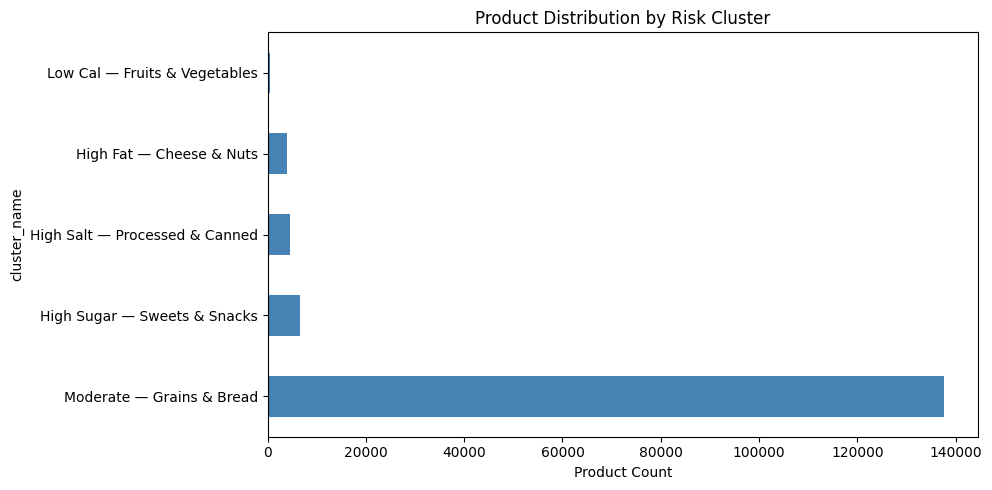

In [24]:
cluster_names = {
    0: 'Moderate — Grains & Bread',
    1: 'High Sugar — Sweets & Snacks',
    2: 'High Fat — Cheese & Nuts',
    3: 'High Salt — Processed & Canned',
    4: 'Low Cal — Fruits & Vegetables'
}

df['cluster_name'] = df['cluster'].map(cluster_names)

df['cluster_name'].value_counts().plot(kind='barh', figsize=(10, 5), color='steelblue')
plt.title('Product Distribution by Risk Cluster')
plt.xlabel('Product Count')
plt.tight_layout()
plt.show()

## 6. Anomaly Detection
We detect abnormal products using Isolation Forest — products with extreme nutritional profiles.

In [25]:

from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
df['anomaly'] = iso.fit_predict(X_cluster_scaled)
scores = iso.decision_function(X_cluster_scaled)

print(df['anomaly'].value_counts())

anomaly
 1    145484
-1      7657
Name: count, dtype: int64


In [26]:
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] == 1]

print("Anomalies:")
print(anomalies[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']].mean().round(2))

print("\nNormal:")
print(normal[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g']].mean().round(2))

Anomalies:
energy_100g      1895.39
fat_100g           28.70
sugars_100g        26.01
proteins_100g      11.29
salt_100g           2.15
dtype: float64

Normal:
energy_100g      1061.21
fat_100g            4.32
sugars_100g         5.81
proteins_100g       6.74
salt_100g           0.70
dtype: float64


In [27]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(n_estimators=200, random_state=42)
lgbm.fit(X_train_scaled, y_train_enc,
         sample_weight=compute_sample_weight(class_weight='balanced', y=y_train_enc))

y_pred_lgbm = lgbm.predict(X_test_scaled)

print(f'LightGBM Accuracy: {accuracy_score(y_test_enc, y_pred_lgbm):.2f}')
print(classification_report(y_test_enc, y_pred_lgbm, target_names=le.classes_))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2050
[LightGBM] [Info] Number of data points in the train set: 122512, number of used features: 9
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Accuracy: 0.55
              precision    recall  f1-score   support

           a       0.50      0.83      0.63      4631
           b       0.34      0.40      0.36      3406
           c       0.46      0.56      0.50      5810
           d       0.61      0.41      0.49      7113
           e       0.76      0.56      0.64      9669

    accuracy                           0.55     30629
   macro avg       0.53      0.55      0.53     30629
weighted avg       0.58      0.55      0.55     30629



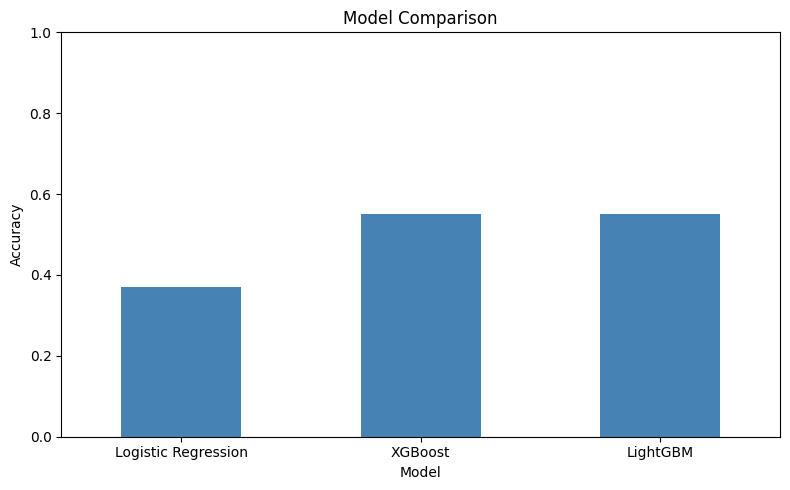

In [28]:
results = {
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'Accuracy': [0.37, 0.55, 0.55]
}

import pandas as pd
results_df = pd.DataFrame(results)

results_df.plot(x='Model', y='Accuracy', kind='bar', figsize=(8, 5), color='steelblue', legend=False)
plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

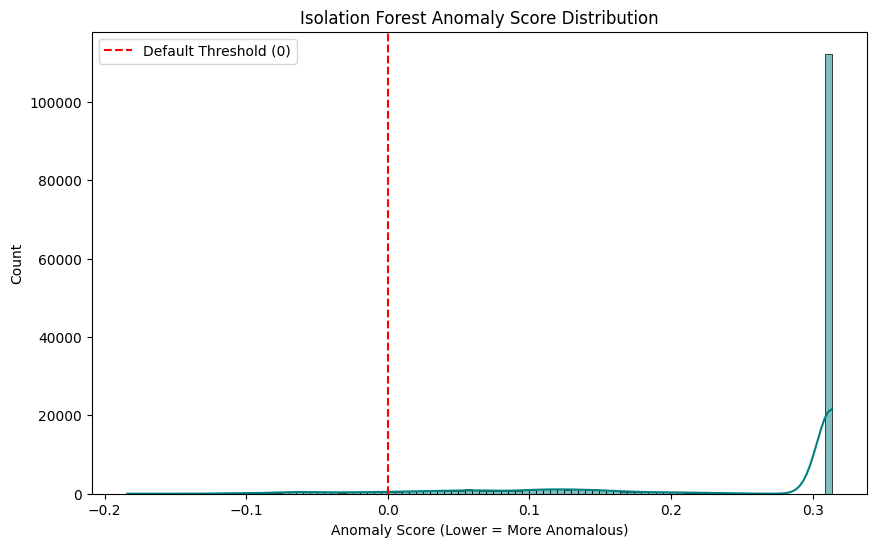

refined_anomaly
 1    152595
-1       546
Name: count, dtype: int64
                    Normal_Mean  Anomaly_Mean  Difference_Ratio
fat_sugar_ratio        1.335538     62.846497         46.057081
energy_per_protein   159.133448   2294.958972         13.421600
fat_100g               5.287662     74.769057         13.140286
cluster                0.186854      2.183150         10.683716
unhealthy_score       12.873436     82.756933          5.428504
salt_100g              0.758004      3.808715          4.024665
energy_100g         1096.162071   2990.637953          1.728281
proteins_100g          6.965045      6.386584         -0.083052
category_enc           4.118700      3.261905         -0.208026
sugars_100g            6.827770      4.179162         -0.387917
refined_anomaly        1.000000     -1.000000         -2.000000
anomaly                0.906799     -1.000000         -2.102780


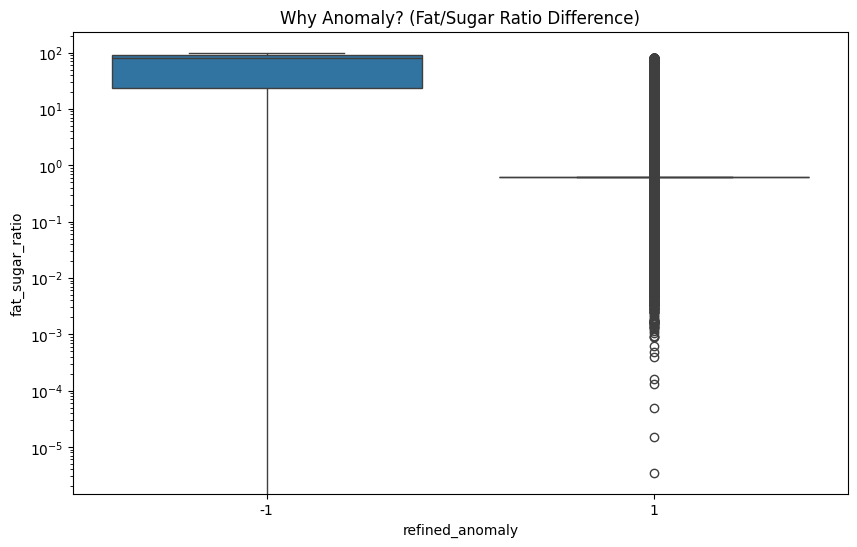

In [32]:
# Anomaly score distribution
plt.figure(figsize=(10, 6))
sns.histplot(scores, bins=100, kde=True, color='teal')
plt.axvline(x=0, color='red', linestyle='--', label='Default Threshold (0)')
plt.title('Isolation Forest Anomaly Score Distribution')
plt.xlabel('Anomaly Score (Lower = More Anomalous)')
plt.ylabel('Count')
plt.legend()
plt.show()

# Refine threshold
df['refined_anomaly'] = np.where(scores < -0.10, -1, 1)
print(df['refined_anomaly'].value_counts())

# Compare normal vs anomaly
normal_products = df[df['refined_anomaly'] == 1]
anomalies = df[df['refined_anomaly'] == -1]

numeric_cols = df.select_dtypes(include=[np.number]).columns
comparison = pd.DataFrame({
    'Normal_Mean': normal_products[numeric_cols].mean(),
    'Anomaly_Mean': anomalies[numeric_cols].mean()
})
comparison['Difference_Ratio'] = (comparison['Anomaly_Mean'] / comparison['Normal_Mean']) - 1
print(comparison.sort_values(by='Difference_Ratio', ascending=False))

# Visualize
plt.figure(figsize=(10, 6))
sns.boxplot(x='refined_anomaly', y='fat_sugar_ratio', data=df)
plt.title('Why Anomaly? (Fat/Sugar Ratio Difference)')
plt.yscale('log')
plt.show()

In [ ]:
import pickle

pickle.dump(xgb3, open('xgb_model.pkl', 'wb'))
pickle.dump(le, open('label_encoder.pkl', 'wb'))

print("Models saved!")

Models saved!


In [38]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# Load models
xgb3 = pickle.load(open('xgb_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))
le = pickle.load(open('label_encoder.pkl', 'rb'))

st.title("FreshGuard — Food Risk Predictor")
st.write("Enter the nutritional values of a product to predict its Nutriscore and risk group.")

energy = st.slider("Energy (per 100g)", 0, 4000, 1000)
fat = st.slider("Fat (per 100g)", 0, 100, 10)
sugars = st.slider("Sugars (per 100g)", 0, 100, 10)
proteins = st.slider("Proteins (per 100g)", 0, 100, 10)
salt = st.slider("Salt (per 100g)", 0, 100, 2)
category_map = {
    'Sugary snacks': 0,
    'Cereals and potatoes': 1,
    'Beverages': 2,
    'Fat and sauces': 3,
    'Milk and dairy products': 4,
    'Fish Meat Eggs': 5,
    'Fruits and vegetables': 6,
    'Composite foods': 7,
    'Salty snacks': 8,
    'Alcoholic beverages': 9,
    'Baby foods': 10
}

category = st.selectbox("Food Category", options=list(category_map.keys()))
category_enc = category_map[category]

fat_sugar_ratio = fat / (sugars + 1)
energy_per_protein = energy / (proteins + 1)
unhealthy_score = fat + sugars + salt

if st.button("Predict"):
    input_data = np.array([[energy, fat, sugars, proteins, salt,
                            fat_sugar_ratio, energy_per_protein,
                            unhealthy_score, category_enc]])

    input_df = pd.DataFrame(input_data, columns=['energy_100g', 'fat_100g', 'sugars_100g',
                                                 'proteins_100g', 'salt_100g', 'fat_sugar_ratio',
                                                 'energy_per_protein', 'unhealthy_score', 'category_enc'])

    input_scaled = scaler.transform(input_df)
    prediction = xgb3.predict(input_scaled)
    grade = le.inverse_transform(prediction)[0]

    st.success(f"Predicted Nutriscore: {grade.upper()}")

    grade_info = {
        'a': '🟢 Very healthy product. Low risk.',
        'b': '🟡 Healthy product. Acceptable.',
        'c': '🟠 Moderate. Consume with caution.',
        'd': '🔴 Unhealthy. High risk of spoilage and low demand.',
        'e': '⛔ Very unhealthy. Highest fire risk in store.'
    }

    st.info(grade_info[grade])



Overwriting app.py


In [39]:
import pickle

# Scaler'ın beklediği sütun isimlerini görelim
print(scaler.feature_names_in_)

['energy_100g' 'fat_100g' 'sugars_100g' 'proteins_100g' 'salt_100g'
 'unhealthy_score']


In [40]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler_app = StandardScaler()
scaler_app.fit(df[['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
                    'fat_sugar_ratio', 'energy_per_protein', 'unhealthy_score', 'category_enc']])

pickle.dump(scaler_app, open('scaler.pkl', 'wb'))
print("Saved!")
print(scaler_app.feature_names_in_)

Saved!
['energy_100g' 'fat_100g' 'sugars_100g' 'proteins_100g' 'salt_100g'
 'fat_sugar_ratio' 'energy_per_protein' 'unhealthy_score' 'category_enc']


## 7. Conclusion
- Best model: XGBoost & LightGBM with 0.55 accuracy
- Most important feature: food category, followed by salt and unhealthy score
- High risk clusters: High Sugar and High Salt products
- Recommendation: Retailers should prioritize monitoring of Sugary Snacks and Processed foods